In [1]:
import os, yaml, sys
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from useful_stuff.general_utils.RSA import dRSA
from project_specific_utils.dataloader import load_img_natraster


In [26]:
@dataclass
class Cfg:
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    new_fs: int = 100
    euclidean_metric: str = "euclidean"
    cosine_metric: str = "cosine_cnt"
    magnitude_metric: str = "magnitude_diff"
    RSA_metric: str = "correlation"
    results_dir: Path = Path(paths["data_path"]) / "results"
    save_results: bool = True

cfg = Cfg()
cfg


Cfg(monkey_name='three0', date='250313', brain_area='AIT', new_fs=100, euclidean_metric='euclidean', cosine_metric='cosine_cnt', magnitude_metric='magnitude_diff', RSA_metric='correlation', results_dir=PosixPath('/Users/tizianocausin/metrics_II_local/results'), save_results=True)

In [27]:
def RDM_timeseries_to_array(RDM_timeseries):
    RDM_array = RDM_timeseries.get_array()
    if isinstance(RDM_array, list):
        RDM_array = np.stack(RDM_array)
    return np.asarray(RDM_array)
# EOF


def compute_RDM_timeseries_for_metrics(raster, metrics, RSA_metric="correlation"):
    drsa_objects = {}
    RDM_timeseries = {}
    RDM_arrays = {}
    for metric in metrics:
        drsa_obj = dRSA(metric, metric, RSA_metric=RSA_metric)
        drsa_obj.compute_RDM_timeseries(raster, "signal")
        drsa_objects[metric] = drsa_obj
        RDM_timeseries[metric] = drsa_obj.get_RDM_timeseries("signal")
        RDM_arrays[metric] = RDM_timeseries_to_array(RDM_timeseries[metric])
    return drsa_objects, RDM_timeseries, RDM_arrays
# EOF


def zscore(x):
    x = np.asarray(x, dtype=float)
    sd = np.nanstd(x)
    if sd == 0 or np.isnan(sd):
        return np.full_like(x, np.nan, dtype=float)
    return (x - np.nanmean(x)) / sd
# EOF


def fit_linear_contributions(euclidean_RDMs, cosine_RDMs, magnitude_RDMs):
    euclidean_RDMs = np.asarray(euclidean_RDMs)
    cosine_RDMs = np.asarray(cosine_RDMs)
    magnitude_RDMs = np.asarray(magnitude_RDMs)
    if euclidean_RDMs.shape != cosine_RDMs.shape or euclidean_RDMs.shape != magnitude_RDMs.shape:
        raise ValueError(
            f"RDM shapes must match: euclidean={euclidean_RDMs.shape}, "
            f"cosine={cosine_RDMs.shape}, magnitude={magnitude_RDMs.shape}"
        )

    n_time = euclidean_RDMs.shape[0]
    beta = np.full((n_time, 3), np.nan)
    beta_standardized = np.full((n_time, 3), np.nan)
    r2 = np.full(n_time, np.nan)
    unique_r2_cosine = np.full(n_time, np.nan)
    unique_r2_magnitude = np.full(n_time, np.nan)
    predictor_corr = np.full(n_time, np.nan)

    for t in range(n_time):
        y = euclidean_RDMs[t]
        x_cosine = cosine_RDMs[t]
        x_magnitude = magnitude_RDMs[t]
        valid = np.isfinite(y) & np.isfinite(x_cosine) & np.isfinite(x_magnitude)
        if valid.sum() < 4:
            continue

        y = y[valid]
        x_cosine = x_cosine[valid]
        x_magnitude = x_magnitude[valid]
        X = np.column_stack([x_cosine, x_magnitude])
        X_design = np.column_stack([np.ones(len(y)), X])

        beta[t] = np.linalg.lstsq(X_design, y, rcond=None)[0]
        y_hat = X_design @ beta[t]
        sse_full = np.sum((y - y_hat) ** 2)
        sst = np.sum((y - y.mean()) ** 2)
        if sst > 0:
            r2[t] = 1 - sse_full / sst

            X_no_cosine = np.column_stack([np.ones(len(y)), x_magnitude])
            beta_no_cosine = np.linalg.lstsq(X_no_cosine, y, rcond=None)[0]
            sse_no_cosine = np.sum((y - X_no_cosine @ beta_no_cosine) ** 2)
            unique_r2_cosine[t] = (sse_no_cosine - sse_full) / sst

            X_no_magnitude = np.column_stack([np.ones(len(y)), x_cosine])
            beta_no_magnitude = np.linalg.lstsq(X_no_magnitude, y, rcond=None)[0]
            sse_no_magnitude = np.sum((y - X_no_magnitude @ beta_no_magnitude) ** 2)
            unique_r2_magnitude[t] = (sse_no_magnitude - sse_full) / sst

        y_z = zscore(y)
        x_cosine_z = zscore(x_cosine)
        x_magnitude_z = zscore(x_magnitude)
        valid_z = np.isfinite(y_z) & np.isfinite(x_cosine_z) & np.isfinite(x_magnitude_z)
        if valid_z.sum() >= 4:
            X_z = np.column_stack([
                np.ones(valid_z.sum()),
                x_cosine_z[valid_z],
                x_magnitude_z[valid_z],
            ])
            beta_standardized[t] = np.linalg.lstsq(X_z, y_z[valid_z], rcond=None)[0]
            predictor_corr[t] = np.corrcoef(x_cosine_z[valid_z], x_magnitude_z[valid_z])[0, 1]

    return {
        "beta": beta,
        "beta_standardized": beta_standardized,
        "r2": r2,
        "unique_r2_cosine": unique_r2_cosine,
        "unique_r2_magnitude": unique_r2_magnitude,
        "predictor_corr": predictor_corr,
    }
# EOF


In [28]:
raster = load_img_natraster(
    paths,
    cfg.monkey_name,
    cfg.date,
    new_fs=cfg.new_fs,
    brain_area=cfg.brain_area,
)

print("raster shape:", raster.get_array().shape)
print("fs:", raster.get_fs())


raster shape: (25, 30, 776)
fs: 100


In [29]:
metrics = (cfg.euclidean_metric, cfg.magnitude_metric, cfg.cosine_metric)
drsa_objects, RDM_timeseries, RDM_arrays = compute_RDM_timeseries_for_metrics(
    raster,
    metrics,
    RSA_metric=cfg.RSA_metric,
)

for metric, RDM_array in RDM_arrays.items():
    print(metric, RDM_array.shape)


euclidean (30, 300700)
magnitude_diff (30, 300700)
cosine_cnt (30, 300700)


In [30]:
# contributions = fit_linear_contributions(
#     RDM_arrays[cfg.euclidean_metric],
#     RDM_arrays[cfg.cosine_metric],
#     RDM_arrays[cfg.magnitude_metric],
# )

# time_bins = np.arange(len(contributions["r2"]))
# save_name = (
#     cfg.results_dir
#     / f"RDM_linear_contributions_{cfg.euclidean_metric}_from_{cfg.cosine_metric}-{cfg.magnitude_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_{cfg.new_fs}Hz.npz"
# )

# if cfg.save_results:
#     cfg.results_dir.mkdir(parents=True, exist_ok=True)
#     np.savez_compressed(
#         save_name,
#         euclidean_RDM_timeseries=RDM_arrays[cfg.euclidean_metric],
#         cosine_RDM_timeseries=RDM_arrays[cfg.cosine_metric],
#         magnitude_RDM_timeseries=RDM_arrays[cfg.magnitude_metric],
#         beta=contributions["beta"],
#         beta_standardized=contributions["beta_standardized"],
#         r2=contributions["r2"],
#         unique_r2_cosine=contributions["unique_r2_cosine"],
#         unique_r2_magnitude=contributions["unique_r2_magnitude"],
#         predictor_corr=contributions["predictor_corr"],
#         metrics=np.array(metrics),
#     )
#     print(f"saved {save_name}")


In [31]:
# fig, ax = plt.subplots(1, 3, figsize=(14, 4), sharex=True)

# ax[0].plot(time_bins, contributions["beta_standardized"][:, 1], linewidth=2, label=cfg.cosine_metric)
# ax[0].plot(time_bins, contributions["beta_standardized"][:, 2], linewidth=2, label=cfg.magnitude_metric)
# ax[0].axhline(0, color="black", linewidth=1, alpha=0.35)
# ax[0].set_ylabel("standardized beta")
# ax[0].set_title("Linear weights")

# ax[1].plot(time_bins, contributions["unique_r2_cosine"], linewidth=2, label=cfg.cosine_metric)
# ax[1].plot(time_bins, contributions["unique_r2_magnitude"], linewidth=2, label=cfg.magnitude_metric)
# ax[1].axhline(0, color="black", linewidth=1, alpha=0.35)
# ax[1].set_ylabel("unique $R^2$")
# ax[1].set_title("Unique variance")

# ax[2].plot(time_bins, contributions["r2"], color="tab:green", linewidth=2, label="full model")
# ax[2].plot(time_bins, contributions["predictor_corr"], color="tab:gray", linewidth=2, alpha=0.8, label="predictor corr")
# ax[2].axhline(0, color="black", linewidth=1, alpha=0.35)
# ax[2].set_ylabel("value")
# ax[2].set_title("Fit and collinearity")

# for a in ax:
#     a.set_xlabel("time bin")
#     a.spines[["top", "right"]].set_visible(False)
#     a.legend(frameon=False)

# fig.suptitle(
#     f"Euclidean RDM linear decomposition | {cfg.monkey_name} {cfg.date} {cfg.brain_area}, {cfg.new_fs} Hz",
#     y=1.05,
# )
# plt.tight_layout()


In [32]:
# fig, ax = plt.subplots(figsize=(8, 4))
# ax.plot(time_bins, contributions["beta"][:, 0], linewidth=2, label="intercept")
# ax.plot(time_bins, contributions["beta"][:, 1], linewidth=2, label=cfg.cosine_metric)
# ax.plot(time_bins, contributions["beta"][:, 2], linewidth=2, label=cfg.magnitude_metric)
# ax.axhline(0, color="black", linewidth=1, alpha=0.35)
# ax.set_xlabel("time bin")
# ax.set_ylabel("raw beta")
# ax.set_title("Raw regression coefficients")
# ax.spines[["top", "right"]].set_visible(False)
# ax.legend(frameon=False)
# plt.tight_layout()


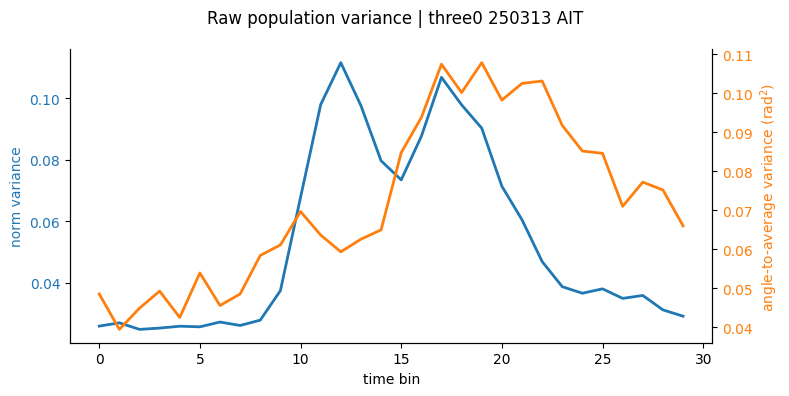

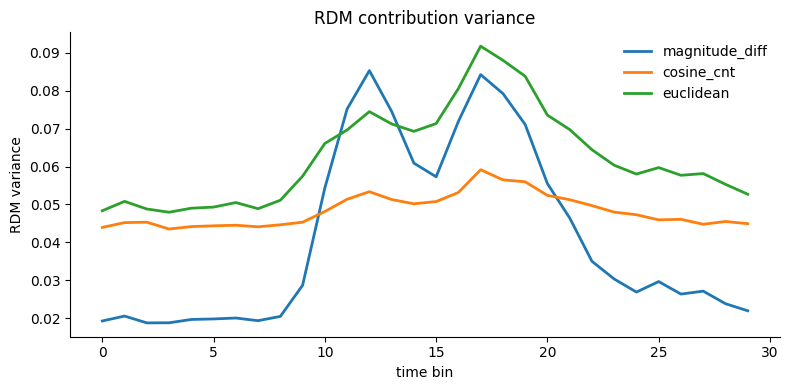

In [37]:
def compute_population_norm_angle_variance(raster):
    raster_array = raster.get_array() if hasattr(raster, "get_array") else np.asarray(raster)
    if raster_array.ndim != 3:
        raise ValueError(f"Expected raster with shape (neurons, time, images), got {raster_array.shape}")

    n_time = raster_array.shape[1]
    norm_variance = np.full(n_time, np.nan)
    angle_variance = np.full(n_time, np.nan)

    for t in range(n_time):
        population_vectors = np.asarray(raster_array[:, t, :], dtype=float)
        valid_images = np.isfinite(population_vectors).all(axis=0)
        population_vectors = population_vectors[:, valid_images]
        if population_vectors.shape[1] < 2:
            continue

        norms = np.linalg.norm(population_vectors, axis=0)
        norm_variance[t] = np.nanvar(norms)

        nonzero = norms > 0
        if nonzero.sum() < 2:
            continue
        population_vectors = population_vectors[:, nonzero]
        norms = norms[nonzero]
        unit_vectors = population_vectors / norms[None, :]

        average_direction = np.nanmean(unit_vectors, axis=1)
        average_direction_norm = np.linalg.norm(average_direction)
        if average_direction_norm == 0 or not np.isfinite(average_direction_norm):
            continue
        average_direction = average_direction / average_direction_norm

        cosine_to_average = np.clip(unit_vectors.T @ average_direction, -1, 1)
        angles_to_average = np.arccos(cosine_to_average)
        angle_variance[t] = np.nanvar(angles_to_average)

    return norm_variance, angle_variance
# EOF

time_bins = np.arange(len(raster))


norm_variance, angle_variance = compute_population_norm_angle_variance(raster)
RDM_variance = {
    metric: np.nanvar(RDM_arrays[metric], axis=1)
    for metric in (cfg.magnitude_metric, cfg.cosine_metric, cfg.euclidean_metric)
}

fig, ax_norm = plt.subplots(figsize=(8, 4))
ax_angle = ax_norm.twinx()
ax_norm.plot(time_bins, norm_variance, color="tab:blue", linewidth=2, label="population norm")
ax_angle.plot(time_bins, angle_variance, color="tab:orange", linewidth=2, label="angle to average direction")
ax_norm.set_xlabel("time bin")
ax_norm.set_ylabel("norm variance", color="tab:blue")
ax_angle.set_ylabel("angle-to-average variance (rad$^2$)", color="tab:orange")
ax_norm.tick_params(axis="y", labelcolor="tab:blue")
ax_angle.tick_params(axis="y", labelcolor="tab:orange")
ax_norm.spines["top"].set_visible(False)
ax_angle.spines["top"].set_visible(False)
fig.suptitle(f"Raw population variance | {cfg.monkey_name} {cfg.date} {cfg.brain_area}")
fig.tight_layout()

fig, ax = plt.subplots(figsize=(8, 4))
for metric, values in RDM_variance.items():
    ax.plot(time_bins, values, linewidth=2, label=metric)
ax.set_xlabel("time bin")
ax.set_ylabel("RDM variance")
ax.set_title("RDM contribution variance")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()


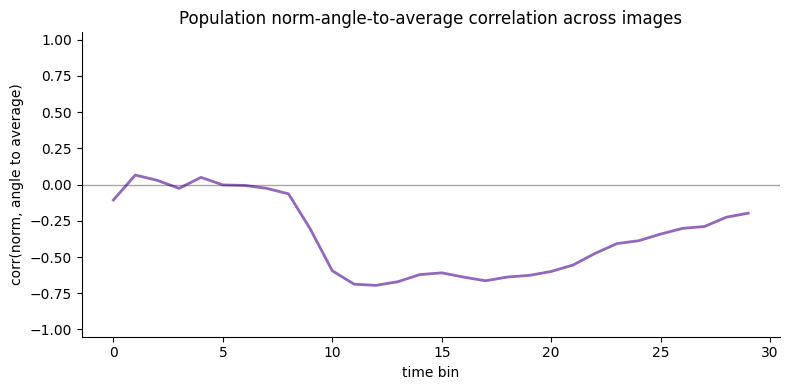

In [39]:
def compute_norm_angle_correlation(raster):
    raster_array = raster.get_array() if hasattr(raster, "get_array") else np.asarray(raster)
    if raster_array.ndim != 3:
        raise ValueError(f"Expected raster with shape (neurons, time, images), got {raster_array.shape}")

    n_time = raster_array.shape[1]
    norm_angle_corr = np.full(n_time, np.nan)

    for t in range(n_time):
        population_vectors = np.asarray(raster_array[:, t, :], dtype=float)
        valid_images = np.isfinite(population_vectors).all(axis=0)
        population_vectors = population_vectors[:, valid_images]
        if population_vectors.shape[1] < 3:
            continue

        norms = np.linalg.norm(population_vectors, axis=0)
        nonzero = norms > 0
        if nonzero.sum() < 3:
            continue

        population_vectors = population_vectors[:, nonzero]
        norms = norms[nonzero]
        unit_vectors = population_vectors / norms[None, :]

        average_direction = np.nanmean(unit_vectors, axis=1)
        average_direction_norm = np.linalg.norm(average_direction)
        if average_direction_norm == 0 or not np.isfinite(average_direction_norm):
            continue
        average_direction = average_direction / average_direction_norm

        cosine_to_average = np.clip(unit_vectors.T @ average_direction, -1, 1)
        angles_to_average = np.arccos(cosine_to_average)

        valid = np.isfinite(norms) & np.isfinite(angles_to_average)
        if valid.sum() >= 3 and np.nanstd(norms[valid]) > 0 and np.nanstd(angles_to_average[valid]) > 0:
            norm_angle_corr[t] = np.corrcoef(norms[valid], angles_to_average[valid])[0, 1]

    return norm_angle_corr
# EOF


norm_angle_corr = compute_norm_angle_correlation(raster)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(time_bins, norm_angle_corr, color="tab:purple", linewidth=2)
ax.axhline(0, color="black", linewidth=1, alpha=0.35)
ax.set_xlabel("time bin")
ax.set_ylabel("corr(norm, angle to average)")
ax.set_title("Population norm-angle-to-average correlation across images")
ax.set_ylim(-1.05, 1.05)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
